In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv("Customer Segmentation.csv")

In [54]:
df.head()

,Unnamed: 0,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,0,460394,Female,No,32,Yes,Healthcare,9.0,Low,3.0,Cat_6,D
1,1,461798,Female,No,56,Yes,Artist,0.0,Low,1.0,Cat_6,A
2,2,464976,Male,Yes,75,No,Lawyer,1.0,Low,1.0,Cat_4,D
3,3,462104,Male,Yes,39,No,Entertainment,9.0,Low,2.0,Cat_3,D
4,4,464829,Male,No,22,No,Healthcare,9.0,Low,5.0,Cat_4,D


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10695 entries, 0 to 10694
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       10695 non-null  int64  
 1   ID               10695 non-null  int64  
 2   Gender           10695 non-null  str    
 3   Ever_Married     10505 non-null  str    
 4   Age              10695 non-null  int64  
 5   Graduated        10593 non-null  str    
 6   Profession       10533 non-null  str    
 7   Work_Experience  9597 non-null   float64
 8   Spending_Score   10695 non-null  str    
 9   Family_Size      10247 non-null  float64
 10  Var_1            10587 non-null  str    
 11  Segmentation     10695 non-null  str    
dtypes: float64(2), int64(3), str(7)
memory usage: 1002.8 KB


In [56]:
# Remove Unnecessary Column
df.drop(columns=['Unnamed: 0'], inplace=True)
df = df.drop('ID', axis=1)

In [57]:
df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,Female,No,32,Yes,Healthcare,9.0,Low,3.0,Cat_6,D
1,Female,No,56,Yes,Artist,0.0,Low,1.0,Cat_6,A
2,Male,Yes,75,No,Lawyer,1.0,Low,1.0,Cat_4,D
3,Male,Yes,39,No,Entertainment,9.0,Low,2.0,Cat_3,D
4,Male,No,22,No,Healthcare,9.0,Low,5.0,Cat_4,D


In [58]:
# Check Missing Values
df.isnull().sum()

Gender                0
Ever_Married        190
Age                   0
Graduated           102
Profession          162
Work_Experience    1098
Spending_Score        0
Family_Size         448
Var_1               108
Segmentation          0
dtype: int64

In [59]:
df.describe()

,Age,Work_Experience,Family_Size
count,10695.000000,9597.000000,10247.000000
mean,43.511828,2.619777,2.844052
std,16.774158,3.390790,1.536427
min,18.000000,0.000000,1.000000
25%,30.000000,0.000000,2.000000
50%,41.000000,1.000000,3.000000
75%,53.000000,4.000000,4.000000
max,89.000000,14.000000,9.000000


#### Since the mean and median values are approximately equal, the distribution appears fairly symmetric with minimal skewness. Therefore, either mean or median imputation could be used. However, median is preferred as it is more robust to potential outliers.

In [60]:
# for Numerical columns
df['Work_Experience'] = df['Work_Experience'].fillna(df['Work_Experience'].median())

df['Family_Size'] = df['Family_Size'].fillna(df['Family_Size'].median())

In [61]:
# For Categorical Columns
df['Profession'] = df['Profession'].fillna(df['Profession'].mode()[0])

df['Ever_Married'] = df['Ever_Married'].fillna(df['Ever_Married'].mode()[0])

df['Graduated'] = df['Graduated'].fillna(df['Graduated'].mode()[0])

df['Var_1'] = df['Var_1'].fillna(df['Var_1'].mode()[0])

In [62]:
df.isnull().sum()

Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
Segmentation       0
dtype: int64

In [63]:
df['Work_Experience'] = df['Work_Experience'].astype(int)
df['Family_Size'] = df['Family_Size'].astype(int)

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10695 entries, 0 to 10694
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Gender           10695 non-null  str  
 1   Ever_Married     10695 non-null  str  
 2   Age              10695 non-null  int64
 3   Graduated        10695 non-null  str  
 4   Profession       10695 non-null  str  
 5   Work_Experience  10695 non-null  int64
 6   Spending_Score   10695 non-null  str  
 7   Family_Size      10695 non-null  int64
 8   Var_1            10695 non-null  str  
 9   Segmentation     10695 non-null  str  
dtypes: int64(3), str(7)
memory usage: 835.7 KB


In [65]:
# convert Object to Category
categorical_cols = ['Gender','Ever_Married','Graduated','Profession',
                    'Spending_Score','Var_1','Segmentation']

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10695 entries, 0 to 10694
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Gender           10695 non-null  category
 1   Ever_Married     10695 non-null  category
 2   Age              10695 non-null  int64   
 3   Graduated        10695 non-null  category
 4   Profession       10695 non-null  category
 5   Work_Experience  10695 non-null  int64   
 6   Spending_Score   10695 non-null  category
 7   Family_Size      10695 non-null  int64   
 8   Var_1            10695 non-null  category
 9   Segmentation     10695 non-null  category
dtypes: category(7), int64(3)
memory usage: 324.1 KB


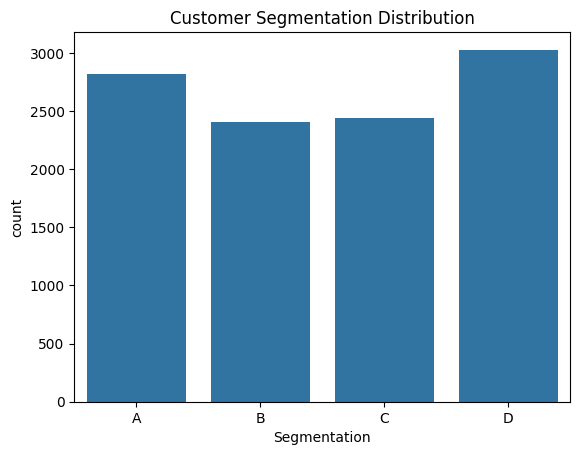

In [67]:
# Segmentation distribution

sns.countplot(x='Segmentation', data=df)
plt.title("Customer Segmentation Distribution")
plt.show()

The dataset contains four customer segments: A, B, C, and D.

Segment D has the highest number of customers, indicating it is the most common group.

Segments B and C have slightly fewer customers compared to A and D.

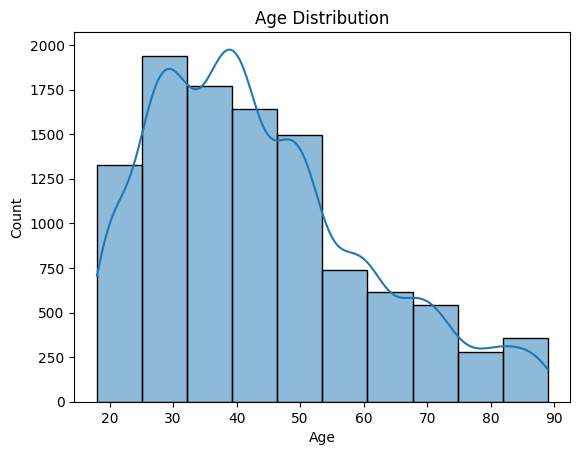

In [49]:
# Age distribution

sns.histplot(df['Age'], bins=10, kde=True)
plt.title("Age Distribution")
plt.show()

Most customers fall in the age range of 25–50 years.

The distribution shows a slight right skew, meaning there are fewer older customers.

Very few customers are above 70 years.

This indicates that the business mainly serves young to middle-aged customers.

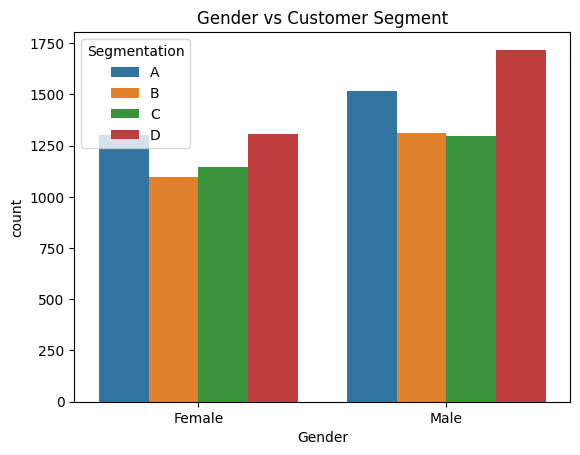

In [50]:
# Gender vs Segmentation

sns.countplot(x='Gender', hue='Segmentation', data=df)
plt.title("Gender vs Customer Segment")
plt.show()

The number of male customers is slightly higher than female customers across all segments.

Segment D has the highest count for both genders.

Customer segmentation does not show a strong gender imbalance, suggesting both genders are distributed fairly evenly across segments.

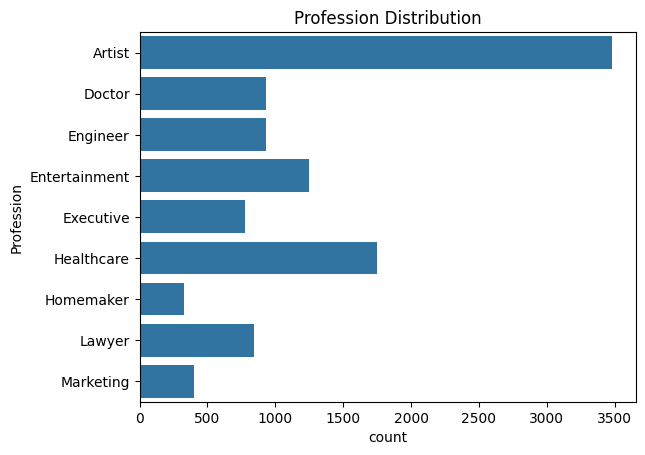

In [51]:
# Profession distribution

sns.countplot(y='Profession', data=df)
plt.title("Profession Distribution")
plt.show()

Artist is the most common profession among customers.

Healthcare and Entertainment also represent a significant portion of customers.

Homemaker and Marketing professions have the lowest counts.

This indicates the customer base is dominated by creative and service-oriented professions.

C:\Users\madha\AppData\Local\Temp\ipykernel_25332\3467575565.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Segmentation', y='Age', data=df, palette='Set2')


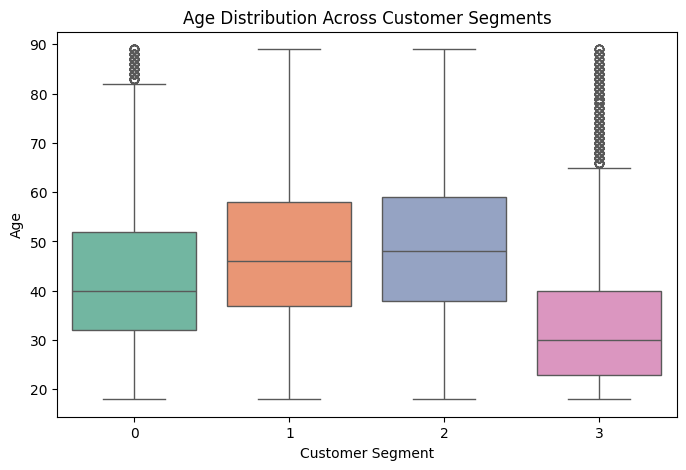

In [73]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Segmentation', y='Age', data=df, palette='Set2')

plt.title("Age Distribution Across Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Age")

plt.show()

Segment C contains relatively older customers.

Segment D mainly consists of younger customers.

Segments A and B have middle-aged customers.

Some high-age outliers (>80) appear in multiple segments.

### Encode Categorical Variables

In [68]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['Gender','Ever_Married','Graduated','Profession',
                    'Spending_Score','Var_1','Segmentation']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

### Feature Scaling

In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

### Find Optimal Number of Clusters

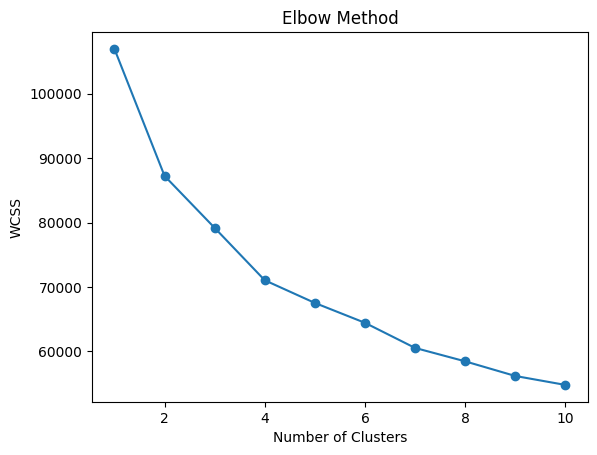

In [71]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [74]:
# Apply KMeans Clustering  (k=4)

kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

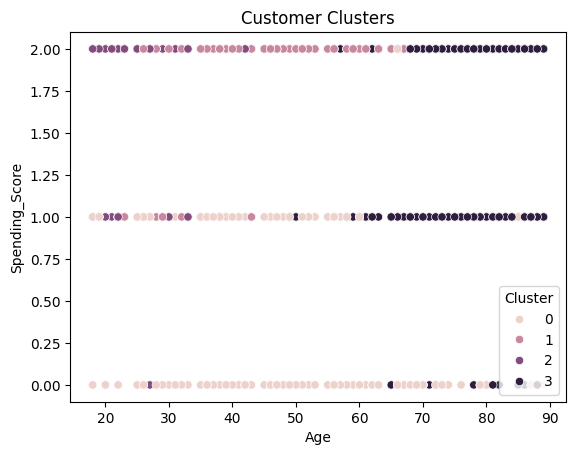

In [75]:
# Visualize Clusters

sns.scatterplot(x=df['Age'], y=df['Spending_Score'], hue=df['Cluster'])
plt.title("Customer Clusters")
plt.show()

In [76]:
cluster_summary = df.groupby('Cluster')[['Age','Work_Experience','Family_Size']].mean().round(2)

cluster_summary

,Age,Work_Experience,Family_Size
Cluster,,,
0,46.89,2.34,3.20
1,40.42,3.18,1.91
2,27.27,2.51,3.91
3,69.64,1.20,2.15


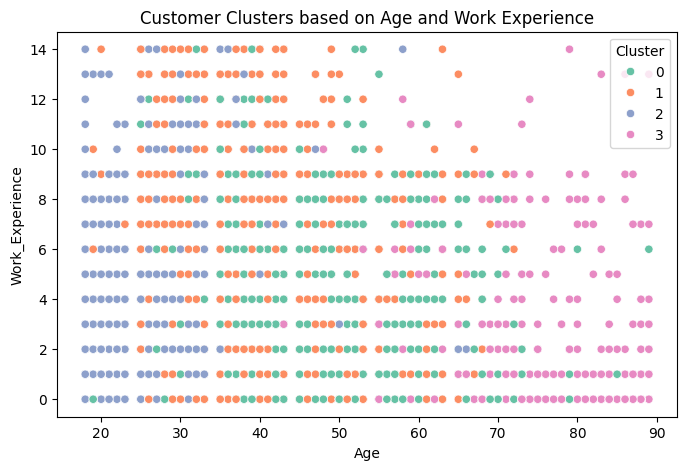

In [77]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Age', y='Work_Experience', hue='Cluster', data=df, palette='Set2')

plt.title("Customer Clusters based on Age and Work Experience")

plt.show()